#### What is Polynomial Regression?
Polynomial Regression is a type of regression analysis where the relationship between the independent variable (x) and dependent variable (y) is modeled as an n-th degree polynomial. It's an extension of linear regression that allows for more complex, non-linear relationships.

#### Mathematical Formula
- Simple Linear Regression:  y = β₀ + β₁x
- Quadratic (degree 2):      y = β₀ + β₁x + β₂x²
- Cubic (degree 3):          y = β₀ + β₁x + β₂x² + β₃x³
- Degree n:                  y = β₀ + β₁x + β₂x² + ... + βₙxⁿ

#### Why Use Polynomial Regression?
1. Real-World Data is Rarely Linear
- Most natural phenomena don't follow straight lines:
- Growth patterns: Population growth often follows exponential curves
- Physics: Projectile motion follows parabolic paths
- Economics: Supply-demand curves are often non-linear
- Medicine: Drug dosage vs. response often has optimal points

2. Capturing Complex Relationships
- Polynomial regression can capture:
- Curvature: Upward/downward trends
- Inflection points: Where trends change direction
- Local maxima/minima: Optimal points in data

#### The Danger: Overfitting with High Degrees
As we increase the polynomial degree:
- Degree 2: Good fit, captures basic curvature
- Degree 5: May fit noise, starts overfitting
- Degree 9: Almost certainly overfits

#### Overfitting Visualization:
- Degree 2:   Smooth curve, good generalization
- Degree 5:   Wiggly, fits training data better but poor test
- Degree 9:   Extremely wiggly, passes through every point, terrible test

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load wine dataset
wine = load_wine()
X = wine.data[:, 0].reshape(-1,1)   #Using 'alchohol' as feature for simplicity
y = wine.target #Target variable

print("Wine Dataset Info:")
print(f"Total samples: {len(X)}")
print(f"Feature used: Alcohol content")
print(f"Target: Wine class (0, 1, 2)")

# Split into train and test sets (80-20%)
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size =0.2,random_state=42
)

print(f"\nTrianing set size: {len(X_train)}")
print(f"\nTest set size: {len(X_test)}")



Wine Dataset Info:
Total samples: 178
Feature used: Alcohol content
Target: Wine class (0, 1, 2)

Trianing set size: 142

Test set size: 36


In [10]:
def train_polynomial_regression(degree, X_train, X_test, y_train, y_test):
    """
    Train polynomial regression model with given degree
    Returns: model, predictions, and metrics
    """
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)  # <-- Fixed typo here ('ploy' -> 'poly')
    X_test_poly = poly.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate metrics
    metrics = {
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred)
    }
    
    return model, poly, y_train_pred, y_test_pred, metrics

# Train Models with different Degrees
# Define degrees to test
degrees = [1, 2, 5, 9]  # Including degree 1 for comparison
results = {}

print("="*60)
print("Training Polynomial Regression Models")
print("="*60)

for degree in degrees:
    print(f"\nTraining degree {degree} polynomial...")
    model, poly, y_train_pred, y_test_pred, metrics = train_polynomial_regression(
        degree, X_train, X_test, y_train, y_test
    )
    
    results[degree] = {
        'model': model,
        'poly': poly,
        'train_pred': y_train_pred,
        'test_pred': y_test_pred,
        'metrics': metrics
    }
    
    print(f"  Train MSE: {metrics['train_mse']:.4f}")
    print(f"  Test MSE:  {metrics['test_mse']:.4f}")
    print(f"  Train R²:  {metrics['train_r2']:.4f}")
    print(f"  Test R²:   {metrics['test_r2']:.4f}")


Training Polynomial Regression Models

Training degree 1 polynomial...
  Train MSE: 0.5404
  Test MSE:  0.5073
  Train R²:  0.0954
  Test R²:   0.1304

Training degree 2 polynomial...
  Train MSE: 0.5054
  Test MSE:  0.4485
  Train R²:  0.1539
  Test R²:   0.2312

Training degree 5 polynomial...
  Train MSE: 0.5003
  Test MSE:  0.4360
  Train R²:  0.1625
  Test R²:   0.2526

Training degree 9 polynomial...
  Train MSE: 0.4982
  Test MSE:  0.4458
  Train R²:  0.1661
  Test R²:   0.2358


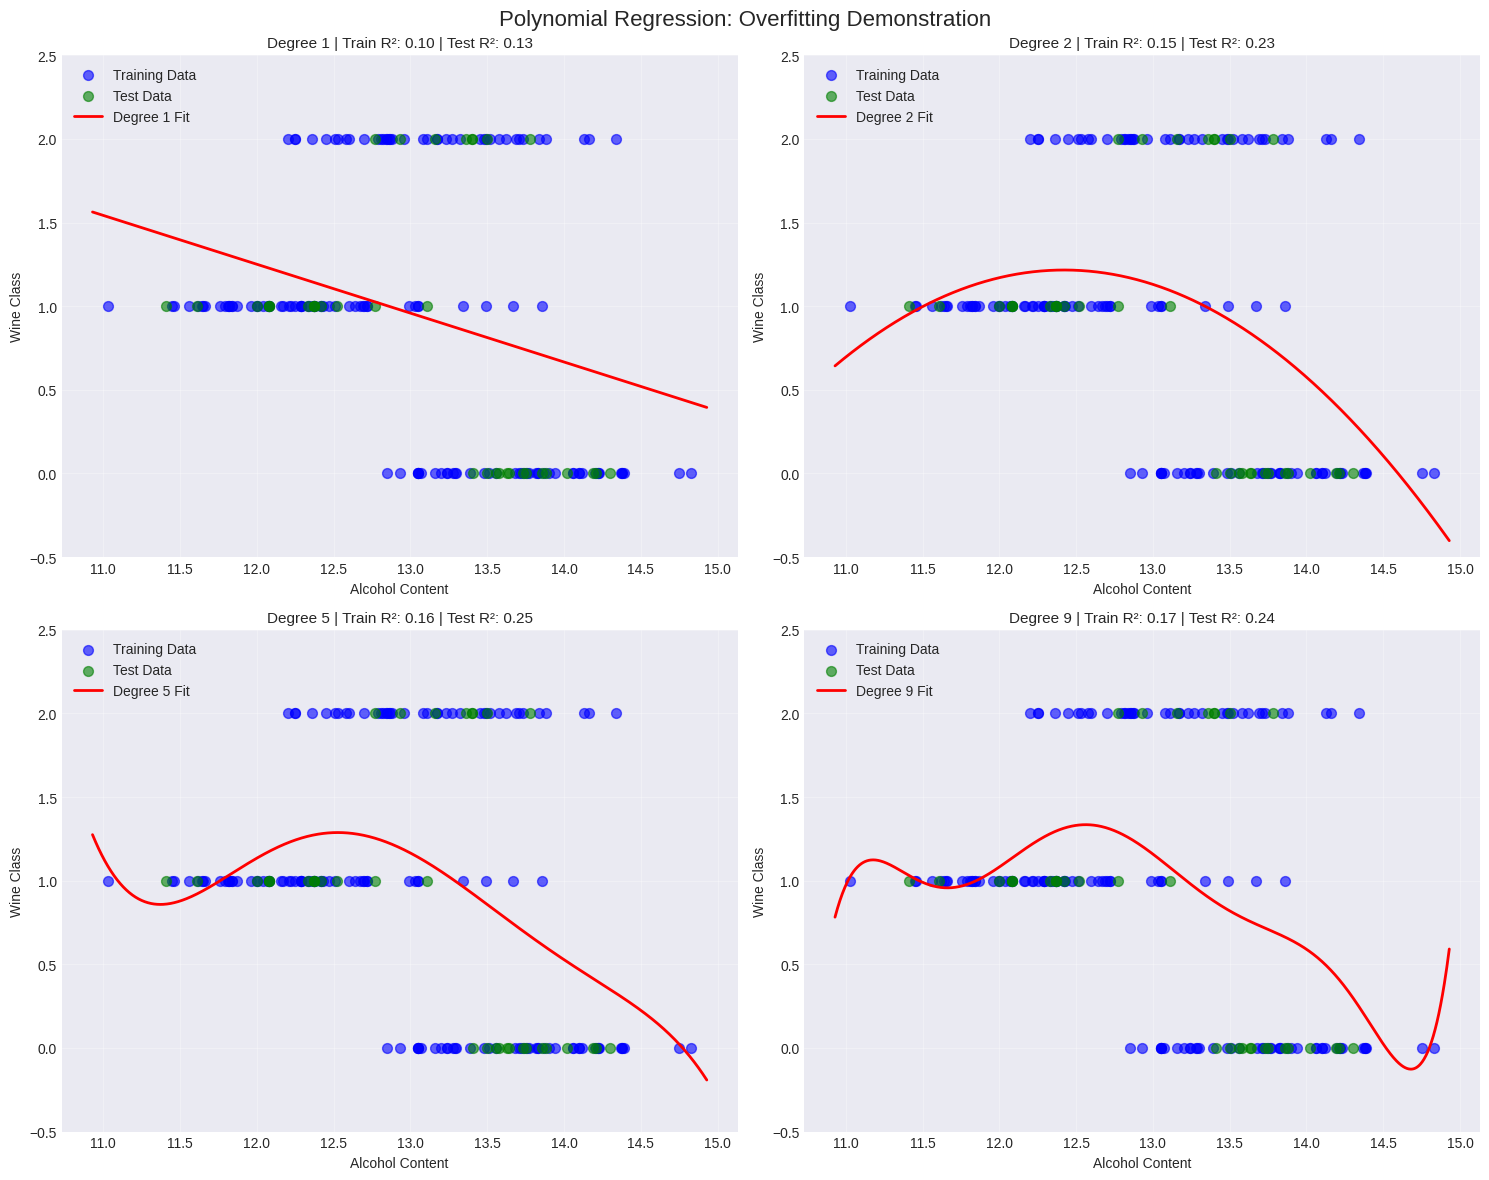

In [13]:
# Create visualization of overfitting
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

X_smooth = np.linspace(X.min() - 0.1, X.max() + 0.1, 1000).reshape(-1, 1)

for idx, degree in enumerate(degrees):
    ax = axes[idx]
    
    model = results[degree]['model']
    poly = results[degree]['poly']
    
    X_smooth_poly = poly.transform(X_smooth)
    y_smooth = model.predict(X_smooth_poly)
    
    ax.scatter(X_train, y_train, color='blue', alpha=0.6, label='Training Data', s=50)
    ax.scatter(X_test, y_test, color='green', alpha=0.6, label='Test Data', s=50)
    ax.plot(X_smooth, y_smooth, color='red', linewidth=2, label=f'Degree {degree} Fit')
    
    # Clip y-limits so degree 9 crazy spikes don't push all data points to the bottom
    ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

    # Metrics placed neatly in the legend box or as title extension
    metrics = results[degree]['metrics']
    
    # Title with metrics included directly
    ax.set_title(f'Degree {degree} | Train R²: {metrics["train_r2"]:.2f} | Test R²: {metrics["test_r2"]:.2f}', fontsize=11)
    
    ax.set_xlabel('Alcohol Content')
    ax.set_ylabel('Wine Class')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial Regression: Overfitting Demonstration', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

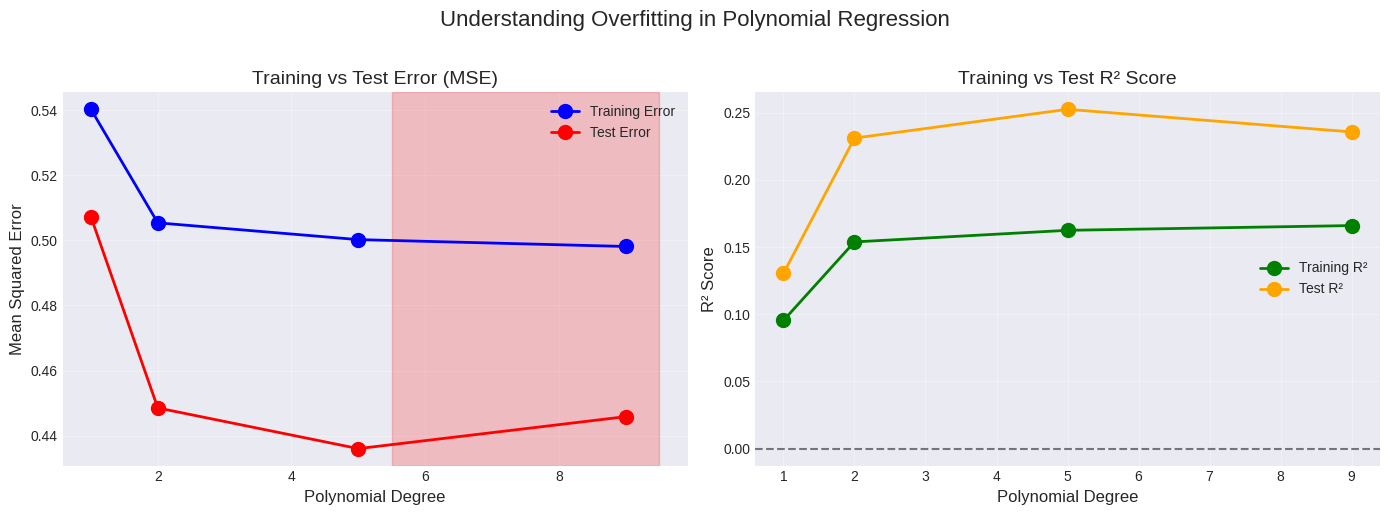

In [14]:
# Error Analysis - The Overfitting Story
# Create error comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Extract metrics for plotting
degrees_list = list(results.keys())
train_errors = [results[d]['metrics']['train_mse'] for d in degrees_list]
test_errors = [results[d]['metrics']['test_mse'] for d in degrees_list]
train_r2 = [results[d]['metrics']['train_r2'] for d in degrees_list]
test_r2 = [results[d]['metrics']['test_r2'] for d in degrees_list]

# Plot MSE
ax1.plot(degrees_list, train_errors, 'o-', linewidth=2, markersize=10, 
         label='Training Error', color='blue')
ax1.plot(degrees_list, test_errors, 'o-', linewidth=2, markersize=10, 
         label='Test Error', color='red')
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Training vs Test Error (MSE)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Highlight overfitting region
ax1.axvspan(5.5, 9.5, alpha=0.2, color='red', label='Overfitting Region')

# Plot R²
ax2.plot(degrees_list, train_r2, 'o-', linewidth=2, markersize=10, 
         label='Training R²', color='green')
ax2.plot(degrees_list, test_r2, 'o-', linewidth=2, markersize=10, 
         label='Test R²', color='orange')
ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('Training vs Test R² Score', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Understanding Overfitting in Polynomial Regression', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



In [15]:
# Detailed Results Table
# Create comparison table
comparison_df = pd.DataFrame({
    'Degree': degrees_list,
    'Train MSE': [results[d]['metrics']['train_mse'] for d in degrees_list],
    'Test MSE': [results[d]['metrics']['test_mse'] for d in degrees_list],
    'Train R²': [results[d]['metrics']['train_r2'] for d in degrees_list],
    'Test R²': [results[d]['metrics']['test_r2'] for d in degrees_list],
    'Train MAE': [results[d]['metrics']['train_mae'] for d in degrees_list],
    'Test MAE': [results[d]['metrics']['test_mae'] for d in degrees_list]
})

print("\n" + "="*70)
print("COMPARISON OF POLYNOMIAL REGRESSION MODELS")
print("="*70)
print(comparison_df.to_string(index=False, float_format=lambda x: '{:.4f}'.format(x)))


COMPARISON OF POLYNOMIAL REGRESSION MODELS
 Degree  Train MSE  Test MSE  Train R²  Test R²  Train MAE  Test MAE
      1     0.5404    0.5073    0.0954   0.1304     0.6224    0.6046
      2     0.5054    0.4485    0.1539   0.2312     0.5772    0.5632
      5     0.5003    0.4360    0.1625   0.2526     0.5736    0.5626
      9     0.4982    0.4458    0.1661   0.2358     0.5682    0.5631


In [18]:
# the Overfitting Analysis
# Calculate overfitting metrics
print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)

for degree in degrees_list:
    train_mse = results[degree]['metrics']['train_mse']
    test_mse = results[degree]['metrics']['test_mse']
    train_r2 = results[degree]['metrics']['train_r2']
    test_r2 = results[degree]['metrics']['test_r2']
    
    # Calculate gap between train and test
    mse_gap = test_mse - train_mse
    r2_gap = train_r2 - test_r2
    
    print(f"\nDegree {degree}:")
    print(f"  MSE Gap (Test - Train): {mse_gap:.4f}")
    print(f"  R² Gap (Train - Test): {r2_gap:.4f}")
    
    if mse_gap > 0.5:
        print(f"Significant overfitting detected!")
    elif mse_gap > 0.2:
        print(f"Some overfitting present")
    else:
        print(f"Good generalization")

# Find best performing model
best_degree = degrees_list[np.argmin([results[d]['metrics']['test_mse'] for d in degrees_list])]
print(f"\nBest performing model: Degree {best_degree}")
print(f"   Test MSE: {results[best_degree]['metrics']['test_mse']:.4f}")
print(f"   Test R²:  {results[best_degree]['metrics']['test_r2']:.4f}")


OVERFITTING ANALYSIS

Degree 1:
  MSE Gap (Test - Train): -0.0331
  R² Gap (Train - Test): -0.0350
Good generalization

Degree 2:
  MSE Gap (Test - Train): -0.0569
  R² Gap (Train - Test): -0.0773
Good generalization

Degree 5:
  MSE Gap (Test - Train): -0.0643
  R² Gap (Train - Test): -0.0901
Good generalization

Degree 9:
  MSE Gap (Test - Train): -0.0524
  R² Gap (Train - Test): -0.0697
Good generalization

Best performing model: Degree 5
   Test MSE: 0.4360
   Test R²:  0.2526


In [20]:
# Compare with Linear Regression
print("\n" + "="*70)
print("COMPARISON WITH LINEAR REGRESSION (YESTERDAY'S MODEL)")
print("="*70)

linear_results = results[1]  # Degree 1 is linear regression
best_results = results[best_degree]

print(f"\nLinear Regression (Degree 1):")
print(f"  Test MSE: {linear_results['metrics']['test_mse']:.4f}")
print(f"  Test R²:  {linear_results['metrics']['test_r2']:.4f}")

print(f"\nBest Polynomial (Degree {best_degree}):")
print(f"  Test MSE: {best_results['metrics']['test_mse']:.4f}")
print(f"  Test R²:  {best_results['metrics']['test_r2']:.4f}")

improvement = ((linear_results['metrics']['test_mse'] - best_results['metrics']['test_mse']) 
               / linear_results['metrics']['test_mse'] * 100)
print(f"\nImprovement with polynomial regression: {improvement:.1f}% reduction in MSE")


COMPARISON WITH LINEAR REGRESSION (YESTERDAY'S MODEL)

Linear Regression (Degree 1):
  Test MSE: 0.5073
  Test R²:  0.1304

Best Polynomial (Degree 5):
  Test MSE: 0.4360
  Test R²:  0.2526

Improvement with polynomial regression: 14.1% reduction in MSE


## Key Takeaways from Our Implementation

### What We Observed

**Degree 1 (Linear):**
*   Simple, interpretable
*   May underfit complex patterns
*   Baseline performance

**Degree 2:**
*   Captures basic curvature
*   Good balance of bias-variance
*   Often the **"sweet spot"**

**Degree 5:**
*   More flexible
*   Starts showing overfitting signs
*   Training error drops, test error increases

**Degree 9:**
*   Extremely flexible
*   **Severe overfitting!**
*   Training error near zero, test error terrible

---

### Visual Signs of Overfitting

| Status | Condition | Description |
| :--- | :--- | :--- |
| ✅ **Good Fit** | `Train error ≈ Test error` | Small gap between metrics |
| ⚠️ **Overfit** | `Train error << Test error` | Large gap (Training much better) |
| ❌ **Underfit** | `Both errors are high` | Model fails to learn patterns |

---

### Why This Matters

*   **Real-world application:** You can now identify when your model is **memorizing** vs. **learning**.
*   **Model selection:** Always use **test error** to choose the right complexity.
*   **Business impact:** Better models lead to **better predictions** and robust decisions.   